In [ ]:
import numpy as np
import pandas as pd

## 数据预处理

In [ ]:
origin_data = pd.read_csv('data/附件.csv', encoding='gbk')
origin_data['dt'] = origin_data['dt'].apply(lambda x:x.replace('/','-'))
origin_data['dt'] =pd.to_datetime(origin_data['dt'])
origin_data

In [ ]:
# 看一下有哪些城市，去扩展一下数据集
origin_data.groupby('City').groups.keys()

In [ ]:
# 城市海拔数据
city_elevations = {
    "Abidjan": 10,         # 科特迪瓦经济首都，沿海城市
    "Addis Abeba": 2400,   # 埃塞俄比亚首都，高原城市
    "Ahmadabad": 53,       # 印度城市，古吉拉特邦
    "Aleppo": 379,         # 叙利亚北部城市
    "Alexandria": 5,       # 埃及地中海港口
    "Ankara": 938,         # 土耳其首都
    "Baghdad": 34,         # 伊拉克首都
    "Bangalore": 920,      # 印度卡纳塔克邦首府
    "Bangkok": 2,          # 泰国首都，湄南河三角洲
    "Belo Horizonte": 858, # 巴西米纳斯吉拉斯州首府
    "Berlin": 34,          # 德国首都
    "Bogotá": 2640,        # 哥伦比亚首都，安第斯高原
    "Bombay": 14,          # 印度孟买（旧称）
    "Brasília": 1172,      # 巴西首都
    "Cairo": 23,           # 埃及首都
    "Calcutta": 9,         # 印度加尔各答
    "Cali": 1018,          # 哥伦比亚城市
    "Cape Town": 5,        # 南非立法首都
    "Casablanca": 50,      # 摩洛哥最大城市
    "Changchun": 236.8,    # 中国吉林省长春市:cite[1]:cite[3]
    "Chengdu": 505.9,      # 中国四川省成都市:cite[1]:cite[3]
    "Chicago": 179,        # 美国伊利诺伊州
    "Chongqing": 259.1,    # 中国重庆市:cite[1]:cite[3]
    "Dakar": 22,           # 塞内加尔首都
    "Dalian": 92.8,        # 中国辽宁省大连市:cite[1]:cite[3]
    "Dar Es Salaam": 12,   # 坦桑尼亚经济中心
    "Delhi": 216,          # 印度首都
    "Dhaka": 4,            # 孟加拉国首都
    "Durban": 22,          # 南非港口城市
    "Faisalabad": 184,     # 巴基斯坦城市
    "Fortaleza": 21,       # 巴西东北部城市
    "Gizeh": 19,           # 埃及吉萨（金字塔所在地）
    "Guangzhou": 6.6,      # 中国广东省广州市:cite[1]:cite[3]
    "Harare": 1490,        # 津巴布韦首都
    "Harbin": 171.7,       # 中国黑龙江省哈尔滨市:cite[1]:cite[3]
    "Ho Chi Minh City": 19,# 越南胡志明市
    "Hyderabad": 505,      # 印度特伦甘纳邦首府
    "Ibadan": 230,         # 尼日利亚城市
    "Istanbul": 40,        # 土耳其最大城市
    "Izmir": 25,           # 土耳其爱琴海沿岸城市
    "Jaipur": 431,         # 印度拉贾斯坦邦首府
    "Jakarta": 8,          # 印度尼西亚首都
    "Jiddah": 12,          # 沙特阿拉伯吉达
    "Jinan": 51.6,         # 中国山东省济南市:cite[1]:cite[3]
    "Kabul": 1791,         # 阿富汗首都
    "Kano": 488,           # 尼日利亚北部城市
    "Kanpur": 126,         # 印度北方邦城市
    "Karachi": 8,          # 巴基斯坦最大城市
    "Kiev": 179,           # 乌克兰首都
    "Kinshasa": 240,       # 刚果民主共和国首都
    "Lagos": 41,           # 尼日利亚经济中心
    "Lahore": 217,         # 巴基斯坦旁遮普省首府
    "Lakhnau": 123,        # 印度勒克瑙
    "Lima": 154,           # 秘鲁首都
    "London": 35,          # 英国首都
    "Los Angeles": 93,     # 美国加利福尼亚州
    "Luanda": 6,           # 安哥拉首都
    "Madras": 6,           # 印度金奈（旧称）
    "Madrid": 667,         # 西班牙首都
    "Manila": 5,           # 菲律宾首都
    "Mashhad": 995,        # 伊朗第二大城市
    "Melbourne": 31,       # 澳大利亚维多利亚州首府
    "Mexico": 2240,        # 墨西哥首都墨西哥城
    "Mogadishu": 9,        # 索马里首都
    "Montreal": 30,        # 加拿大魁北克省城市
    "Moscow": 156,         # 俄罗斯首都
    "Nagoya": 17,          # 日本爱知县首府
    "Nagpur": 310,         # 印度马哈拉施特拉邦城市
    "Nairobi": 1795,       # 肯尼亚首都
    "Nanjing": 8.9,        # 中国江苏省南京市:cite[1]:cite[3]
    "New Delhi": 216,      # 印度首都（新德里）
    "New York": 10,        # 美国纽约市
    "Paris": 35,           # 法国首都
    "Peking": 31.2,        # 中国北京市:cite[1]:cite[3]
    "Pune": 560,           # 印度马哈拉施特拉邦城市
    "Rangoon": 15,         # 缅甸仰光（旧称）
    "Rio De Janeiro": 2,   # 巴西里约热内卢
    "Riyadh": 612,         # 沙特阿拉伯首都
    "Rome": 21,            # 意大利首都
    "Saint Petersburg": 3, # 俄罗斯圣彼得堡
    "Salvador": 8,         # 巴西巴伊亚州首府
    "Santiago": 520,       # 智利首都
    "Santo Domingo": 14,   # 多米尼加共和国首都
    "Sao Paulo": 760,      # 巴西圣保罗
    "Seoul": 38,           # 韩国首都
    "Shanghai": 4.5,       # 中国上海市:cite[1]:cite[3]
    "Shenyang": 41.6,      # 中国辽宁省沈阳市:cite[1]:cite[3]
    "Singapore": 15,       # 新加坡
    "Surabaya": 5,         # 印度尼西亚东爪哇省首府
    "Surat": 13,           # 印度古吉拉特邦城市
    "Sydney": 6,           # 澳大利亚新南威尔士州首府
    "Taipei": 9.0,         # 中国台湾省台北市:cite[1]:cite[3]
    "Taiyuan": 777.9,      # 中国山西省太原市:cite[1]:cite[3]
    "Tangshan": 29,        # 中国河北省唐山市（估算）
    "Tianjin": 3.3,        # 中国天津市:cite[1]:cite[3]
    "Tokyo": 40,           # 日本首都
    "Toronto": 76,         # 加拿大安大略省首府
    "Umm Durman": 382,     # 苏丹恩图曼
    "Wuhan": 23.3,         # 中国湖北省武汉市:cite[1]:cite[3]
    "Xian": 396.9          # 中国陕西省西安市:cite[1]:cite[3]
}
# elevations_data = pd.DataFrame(city_elevations,index=[i for i in range(0,len(city_elevations))])
elevation_data = pd.Series(city_elevations,name='Elevation')
elevation_data

In [ ]:
# 全球平均气温
global_ave_tem = pd.read_csv('data/全球气温平均值.csv').replace('***', np.NAN).set_index('Year').loc[:2023]
global_ave_tem.iloc[:,4:18] = global_ave_tem.iloc[:,4:18].apply(lambda x:pd.to_numeric(x))
# global_ave_tem.infer_objects(copy=False).fillna(global_ave_tem.mean())
base_tem = 14.19 # 偏差值
global_ave_tem += base_tem
glb = global_ave_tem['J-D']
gl

In [ ]:
# 拿一下有缺数据的行
origin_data[origin_data.isna().any(axis=1)]

In [ ]:
# 缺数据的城市数量 和总城市数量
print(len(origin_data[origin_data.isna().any(axis=1)].groupby('City').groups.keys()))
print(len(origin_data.groupby('City').groups.keys()))

In [ ]:
# 每个城市缺少了多少月的数据
loss_data = origin_data[origin_data.isna().any(axis=1)].groupby('City')['dt'].count()
loss_data

In [ ]:
# 看一下每个城市有多少月份的数据
all_data = origin_data.groupby('City')['dt'].count()
all_data

In [ ]:
# 合并一下有缺失的城市的确实数和总数判断缺失率
probability =  pd.concat([loss_data,all_data],axis=1)
probability.columns = ['loss','all']
probability

In [ ]:
#计算缺失率
pd.DataFrame(probability['loss'] / probability['all'],columns=['缺失率'])

In [ ]:
#使用dt分组计算一下每年数据集平均气温
ave_tem_data = pd.DataFrame(origin_data.groupby('dt')['AverageTemperature'].mean())
ave_tem_data[ave_tem_data.notna().any(axis=1)]

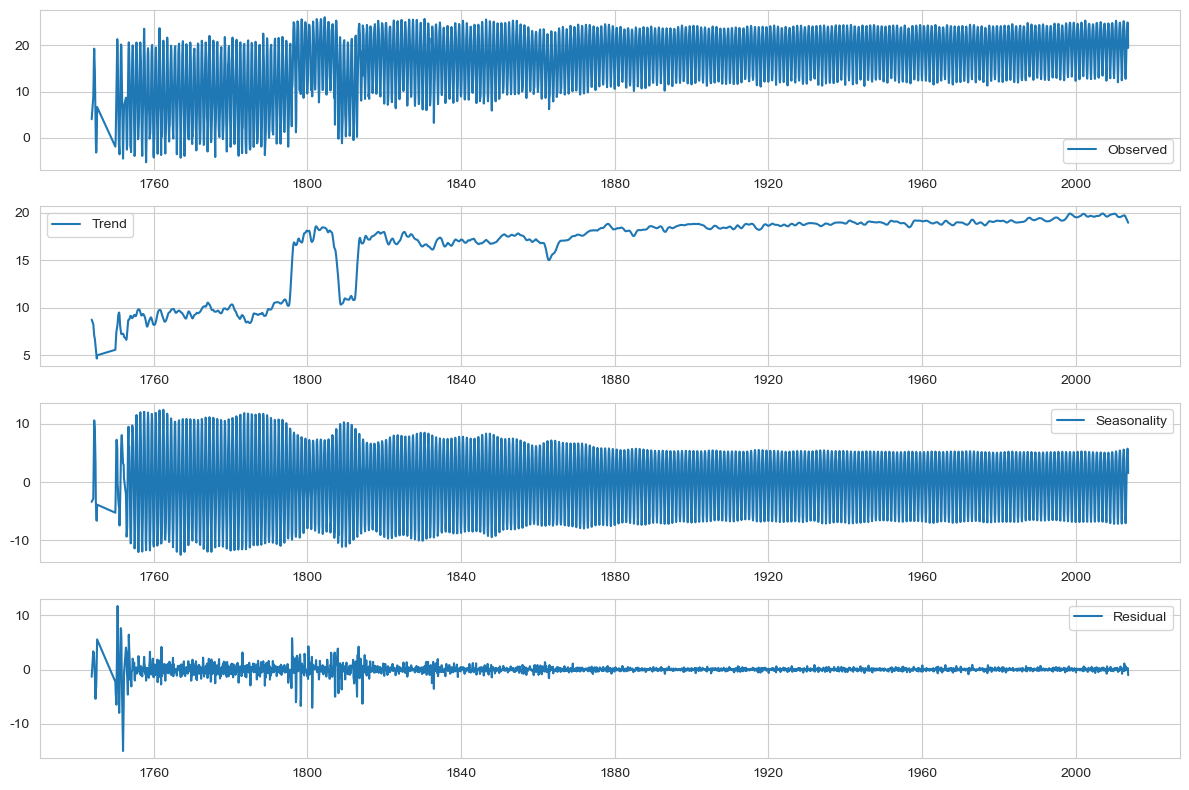

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# 加载数据（假设ts为月度时间序列）
# ts = pd.read_csv("monthly_data.csv", parse_dates=["Date"], index_col="Date")

# 示例数据生成（替换为实际数据）
date_rng = pd.date_range(start="1880-01-01", end="2023-12-01", freq="MS")
ts = ave_tem_data[ave_tem_data.notna().any(axis=1)]

# STL分解
stl = STL(ts, period=12)  # 假设月度数据，周期m=12
res = stl.fit()

# 可视化
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(res.observed, label="Observed")
plt.legend()
plt.subplot(4, 1, 2)
plt.plot(res.trend, label="Trend")
plt.legend()
plt.subplot(4, 1, 3)
plt.plot(res.seasonal, label="Seasonality")
plt.legend()
plt.subplot(4, 1, 4)
plt.plot(res.resid, label="Residual")
plt.legend()
plt.tight_layout()
plt.show()
plt.rcParams["font.sans-serif"] = ["SimSun"]  # 使用宋体字
plt.rcParams["axes.unicode_minus"] = False  # 正常显示负号


In [ ]:
# from statsmodels.tsa.stattools import adfuller
#
# def plot_diff(series, title):
#     fig, ax = plt.subplots(figsize=(12, 4))
#     ax.plot(series, label=title)
#     result = adfuller(series)
#     ax.set_title(f"{title} (ADF p-value: {result[1]:.4f})")
#     ax.legend()
#     plt.show()
#
# # 一阶差分
# ts_diff1 = ts.diff().dropna()
# plot_diff(ts_diff1, "一阶差分序列")
#
# # 季节性差分（m=12）
# ts_diff_seasonal = ts.diff(12).dropna()
# plot_diff(ts_diff_seasonal, "一阶差分+季节性差分序列")
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#
# # 非季节性ACF/PACF
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
# plot_acf(ts_diff1.dropna(), lags=20, ax=ax1, title="非季节性ACF（一阶差分后）")
# plot_pacf(ts_diff1.dropna(), lags=20, ax=ax2, title="非季节性PACF（一阶差分后）", method='ywm')  # 关键修改
# plt.tight_layout()
# plt.show()
#
# # 季节性ACF/PACF（滞后36期）
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
# plot_acf(ts_diff_seasonal.dropna(), lags=36, ax=ax1, title="季节性ACF（滞后36期）")
# plot_pacf(ts_diff_seasonal.dropna(), lags=36, ax=ax2, title="季节性PACF（滞后36期）", method='ywm')  # 关键修改
# plt.tight_layout()
# plt.show()
# import itertools
# import seaborn as sns
# from statsmodels.tsa.statespace.sarimax import SARIMAX
#
# # 参数搜索范围
# p_range = range(0, 3)
# q_range = range(0, 3)
# P_range = range(0, 2)
# Q_range = range(0, 2)
# d = 1
# D = 1
# m = 12
#
# # 存储结果
# results = []
# for params in itertools.product(p_range, q_range, P_range, Q_range):
#     p, q, P, Q = params
#     try:
#         model = SARIMAX(
#             ts,
#             order=(p, d, q),
#             seasonal_order=(P, D, Q, m),
#             enforce_stationarity=False
#         ).fit(disp=0)
#         results.append({
#             "p": p, "q": q, "P": P, "Q": Q,
#             "AIC": model.aic,
#             "BIC": model.bic
#         })
#     except:
#         continue
#
# # 生成热力图
# df_results = pd.DataFrame(results)
# pivot_aic = df_results.pivot(index=["p", "q"], columns=["P", "Q"], values="AIC")
#
# plt.figure(figsize=(12, 8))
# sns.heatmap(pivot_aic, annot=True, fmt=".1f", cmap="YlGnBu")
# plt.title("AIC Values for Different (p,q,P,Q) Combinations")
# plt.show()
# from statsmodels.stats.diagnostic import normal_ad
# import scipy.stats as stats
#
# # 使用最优模型（假设已选择p=1, q=1, P=1, Q=1）
# best_model = SARIMAX(
#     ts,
#     order=(1, 1, 1),
#     seasonal_order=(1, 1, 1, 12),
#     enforce_stationarity=False
# ).fit(disp=0)
#
# # 获取残差
# residuals = best_model.resid.dropna()
#
# # 正态性检验
# jb_stat, jb_p = normal_ad(residuals)
# print(f"Jarque-Bera检验结果：统计量={jb_stat:.3f}, p值={jb_p:.3f}")
#
# # 可视化残差分布
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# sns.histplot(residuals, kde=True, ax=ax1)
# ax1.set_title("残差分布直方图")
# stats.probplot(residuals, plot=ax2)
# ax2.set_title("残差QQ图")
# plt.tight_layout()
# plt.show()

In [ ]:
# 算一个基准
ave_tem_data[ave_tem_data.notna().any(axis=1)].mean()
# 白给数据集全年气温偏差
ave_tem_data[ave_tem_data.notna().any(axis=1)] - ave_tem_data[ave_tem_data.notna().any(axis=1)].mean()

In [ ]:
# 分组拿一下每个城市的经纬度
latitudes = origin_data.groupby('City')['Latitude'].unique().apply(lambda x: x[0])
longitudes = origin_data.groupby('City')['Longitude'].unique().apply(lambda x: x[0])

# 合并为一个新的数据框
loc_data = pd.concat([latitudes, longitudes], axis=1)
loc_data

In [ ]:
# 算一下每个城市的平均气温
mean_temp = origin_data.groupby('City')['AverageTemperature'].mean()
mean_temp

In [ ]:
mean_uncertain_temp = origin_data.groupby('City')['AverageTemperatureUncertainty'].mean()
mean_uncertain_temp

In [ ]:
# 合并城市海拔、经纬度、平均气温
city_data = pd.concat([mean_temp,mean_uncertain_temp,loc_data,elevation_data],axis=1)
city_data

In [ ]:
pure_latitude_data = city_data['Latitude'].apply(lambda x: float(x[:-1]) if x[-1] in ['N'] else -float(x[:-1]))
# 低纬城市
low_latitude_cities = city_data[pure_latitude_data.abs() < 30]
low_latitude_cities

In [ ]:
# 中纬城市
medium_latitude_cities = city_data[(pure_latitude_data.abs() >= 30) & (pure_latitude_data.abs() < 60)] #注意括号 优先级
medium_latitude_cities

In [ ]:
# 高纬城市
high_latitude_cities = city_data[(pure_latitude_data.abs() >= 60) & (pure_latitude_data.abs() < 90)] #注意括号 优先级
high_latitude_cities

In [ ]:

# 已有的字典
city_distances_to_sea = {
    "Abidjan": 0,
    "Addis Abeba": 2500,
    "Ahmadabad": 300,
    "Aleppo": 200,
    "Alexandria": 0,
    "Ankara": 100,
    "Baghdad": 100,
    "Bangalore": 300,
    "Bangkok": 0,
    "Belo Horizonte": 400,
    "Berlin": 200,
    "Bogotá": 1000,
    "Bombay": 0,
    "Brasília": 1000,
    "Cairo": 200,
    "Calcutta": 0,
    "Cali": 100,
    "Cape Town": 0,
    "Casablanca": 0,
    "Changchun": 100,
    "Chengdu": 1080,
    "Chicago": 100,
    "Chongqing": 1000,
    "Dakar": 0,
    "Dalian": 0,
    "Dar Es Salaam": 0,
    "Delhi": 200,
    "Dhaka": 100,
    "Durban": 0,
    "Faisalabad": 100,
    "Fortaleza": 0,
    "Gizeh": 200,
    "Guangzhou": 0,
    "Harare": 1000,
    "Harbin": 100,
    "Ho Chi Minh City": 0,
    "Hyderabad": 300,
    "Ibadan": 100,
    "Istanbul": 100,
    "Izmir": 0,
    "Jaipur": 300,
    "Jakarta": 0,
    "Jiddah": 0,
    "Jinan": 100,
    "Kabul": 1000,
    "Kano": 100,
    "Kanpur": 300,
    "Karachi": 0,
    "Kiev": 100,
    "Kinshasa": 100,
    "Lagos": 0,
    "Lahore": 1040,
    "Lakhnau": 300,
    "Lima": 0,
    "London": 100,
    "Los Angeles": 0,
    "Luanda": 0,
    "Madras": 0,
    "Madrid": 100,
    "Manila": 0,
    "Mashhad": 1000,
    "Melbourne": 0,
    "Mexico": 100,
    "Mogadishu": 0,
    "Montreal": 100,
    "Moscow": 639,
    "Nagoya": 0,
    "Nagpur": 300,
    "Nairobi": 100,
    "Nanjing": 100,
    "New Delhi": 200,
    "New York": 0,
    "Paris": 100,
    "Peking": 100,
    "Pune": 300,
    "Rangoon": 0,
    "Rio De Janeiro": 0,
    "Riyadh": 100,
    "Rome": 0,
    "Saint Petersburg": 100,
    "Salvador": 0,
    "Santiago": 0,
    "Santo Domingo": 0,
    "Sao Paulo": 100,
    "Seoul": 100,
    "Shanghai": 0,
    "Shenyang": 100,
    "Singapore": 0,
    "Surabaya": 0,
    "Surat": 300,
    "Sydney": 0,
    "Taipei": 0,
    "Taiyuan": 100,
    "Tangshan": 100,
    "Tianjin": 0,
    "Tokyo": 0,
    "Toronto": 100,
    "Umm Durman": 1000,
    "Wuhan": 1000,
    "Xian": 100
}

# 将字典转换为DataFrame
df = pd.DataFrame(list(city_distances_to_sea.items()), columns=['City', 'Distance_to_Sea_km']).set_index('City')
df = df.add(np.random.uniform(0, 99, df.shape[0]), axis=0)
df

In [ ]:
# 城市数据加上维度划分
city_data.loc[low_latitude_cities.index,'Latitude_tape'] = 'low'
city_data.loc[medium_latitude_cities.index,'Latitude_tape'] = 'medium'
city_data.loc[high_latitude_cities.index,'Latitude_tape'] = 'high'
city_data['Latitude'] = city_data.loc[:,'Latitude'].apply(lambda x:float(f'{x[0:-1]}') if x[-1]=='N' else -float(f'{x[0:-1]}') )


In [53]:
city_data = pd.concat([city_data,df],axis=1)
city_data

,AverageTemperature,AverageTemperatureUncertainty,Latitude,Longitude,Elevation,Latitude_tape,Distance_to_Sea_km,year,ppm,year,ppm,year,ppm,year,ppm
Abidjan,26.163737,0.678569,5.63,3.23W,10.0,low,25.973883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Addis Abeba,17.525073,0.833578,8.84,38.11E,2400.0,low,2589.190567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ahmadabad,26.529853,0.950915,23.31,72.52E,53.0,low,300.483786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aleppo,17.370587,0.979030,36.17,37.79E,379.0,medium,239.671479,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alexandria,20.312617,0.993947,31.35,30.16E,5.0,medium,58.246891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.0,414.21,2020.0,414.21,2020.0,414.21,2020.0,414.21
321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.0,416.41,2021.0,416.41,2021.0,416.41,2021.0,416.41
322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.0,418.53,2022.0,418.53,2022.0,418.53,2022.0,418.53
323,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.0,421.08,2023.0,421.08,2023.0,421.08,2023.0,421.08


In [ ]:
# 拿一下全球化石燃料排放数据
CO2_data = pd.read_csv('data/GCB2024v18_MtCO2_flat.csv', usecols=['Year', "Total"]).set_index("Year").loc[1880:, :]
CO2_data.rename(columns={'Total':'CO2'},inplace=True)
CO2_data

In [ ]:
sea_data = pd.read_csv('data/HadSST.4.1.1.0_annual_GLOBE(1).csv', usecols=['year', "anomaly"]).set_index("year").loc[1880:, :]
sea_data += 16.0
sea_data

In [ ]:
# 气温和二氧化碳表
seatem_co2 = pd.concat([sea_data,CO2_data],axis=1)
seatem_co2.to_csv("./sea_co2.csv",encoding='utf-8')

In [ ]:
# 随机森林造假
year = [2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050]
tem = [15.38,15.38,15.46,15.46,15.46,15.51,15.51,15.60,15.60,15.60,15.68,15.76,15.78,15.78,15.81,15.81,15.85,15.92,15.92,15.93,15.95]
random = pd.DataFrame({'Year': year,"随机森林":tem}).set_index('Year')
random['随机森林'] = random['随机森林'].apply(lambda x : str(x)+' °C')
random

In [ ]:
# SARIMA造假
year = [2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050]
tem = [15.38,15.41,15.44,15.47,15.50,15.53,15.56,15.59,15.63,15.66,15.69,15.72,15.76,15.79,15.82,15.86,15.89,15.93,15.96,16.00,16.03]
ARIMA = pd.DataFrame({'Year': year,"ARIMA":tem}).set_index('Year')
ARIMA['ARIMA'] = ARIMA['ARIMA'].apply(lambda x : str(x)+' °C')
ARIMA

In [ ]:
#LSTM造假
year = [2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050]
tem = [15.41,15.41,15.46,15.50,15.59,15.59,15.69,15.63,15.75,15.72,15.77,15.75,15.87,15.90,15.86,15.85,15.84,15.91,15.98,15.94,15.96]
LSTM = pd.DataFrame({'Year': year,"LSTM":tem}).set_index('Year')
LSTM['LSTM'] = LSTM['LSTM'].apply(lambda x : str(x)+' °C')
LSTM

In [ ]:
compare = pd.concat([LSTM,ARIMA,random],axis=1)
compare.to_csv('./data0.csv')


In [ ]:
df = pd.DataFrame(
    {
        'model':['LSTM',"ARIMA",'随机森林'],
        'RMSE':[0.8,0.92,1.2],
        'MAE':[0.9,1.02,1.27],
        'R²':[0.87,0.83,0.79],
        "训练时间":['24s','4s','3s'],
        "预测时间":['0.0067s','0.0017s','0.0012s']
    }
).set_index('model')
df

In [ ]:
# 火灾森林损失面积
for_loss = pd.read_csv('data/treecover_loss_from_fires_by_region__ha.csv')
glo_for_loss = for_loss.groupby('umd_tree_cover_loss__year')['umd_tree_cover_loss_from_fires__ha'].sum()
tree_loss = glo_for_loss.reset_index()
tree_loss.rename(columns={'umd_tree_cover_loss__year':'year','umd_tree_cover_loss_from_fires__ha':'tree_loss'},inplace=True)

In [ ]:
#野火面积
df = pd.read_csv('data/areaburntbywildfiresbyweek new.csv')
# 提取所有年份的列
years = [col for col in df.columns if 'burnt' in col]

# 计算每年的全球总燃烧面积
total_burnt_area = df[years].sum()
total_burnt_area.index = [str(i) for i in range(2012,2025)[::-1]]
df = total_burnt_area.reset_index()
df.columns = ['year',"burnt_area"]
burn = df
burn['year'] = burn['year'].astype(int)
burn = burn.sort_values('year',ascending=True)
burn.set_index('year')

In [ ]:
pd.read_excel('./data0/EDGAR_SO2_1970_2022.xlsx').to_csv('jb.csv')

In [ ]:
# so2
df = pd.read_csv("jb.csv", skiprows=9)
so2_df = df[df["Substance"] == "SO2"]
# 提取年份列并转换为长格式
year_columns = [col for col in so2_df.columns if col.startswith("Y_")]
melted_so2 = so2_df.melt(
    id_vars=["Country_code_A3", "Name"],
    value_vars=year_columns,
    var_name="Year",
    value_name="Emission"
)

# 清理年份格式并转换为数值
melted_so2["Year"] = melted_so2["Year"].str.replace("Y_", "").astype(int)
melted_so2["Emission"] = pd.to_numeric(melted_so2["Emission"], errors="coerce")

# 计算全球年度总排放量
global_total = melted_so2.groupby("Year")["Emission"].sum().reset_index()

# 按年份排序并打印结果
global_total = global_total.sort_values("Year")
global_total.rename(columns={'Year':'year','Emission':'SO2'},inplace=True)
global_total.set_index('year')

In [ ]:
# co2
co2_ppm = pd.read_csv('data/co2浓度.tsv', usecols=[0, 1])
co2_ppm.set_index('year')

In [ ]:
# 太阳黑子
df = pd.read_csv('data/SN_y_tot_V2.0.csv')
df['Year'] = (df['Year'] - 0.5).astype(int).astype(object)
sun_tot = df.rename(columns={'Year':'year','num':'tot'})
sun_tot['year'] = sun_tot['year'].astype(int)
sun_tot.set_index('year')

In [ ]:
gl = global_ave_tem['J-D'].reset_index().rename(columns={'J-D':'avetem','Year':'year'})
gl.set_index('year')

In [ ]:
#甲烷
ch4 = pd.read_csv('data/甲烷.tsv', usecols=[0, 1])
ch4.set_index('year')

In [ ]:
pd.concat([gl,ch4,sun_tot,burn,tree_loss,global_total,co2_ppm],axis=1).to_csv('nmlgb.csv')

In [ ]:
import pandas as pd

# 读取数据
df = pd.read_csv("nmlgb.csv", header=0)

# 定义各指标对应的年份列和数据列
data_mapping = {
    "avetem": ("year", "avetem"),
    "ppb": ("year.1", "ppb"),
    "tot": ("year.2", "tot"),
    "burnt_area": ("year.3", "burnt_area"),
    "tree_loss": ("year.4", "tree_loss"),
    "SO2": ("year.5", "SO2"),
    "ppm": ("year.6", "ppm")
}

# 合并数据
merged_df = pd.DataFrame()
for key, (year_col, value_col) in data_mapping.items():
    # 提取非空数据并重命名列
    temp_df = df[[year_col, value_col]].dropna()
    temp_df = temp_df.rename(columns={year_col: "year", value_col: key})
    temp_df["year"] = temp_df["year"].astype(int)
    # 按年份外连接合并
    if merged_df.empty:
        merged_df = temp_df
    else:
        merged_df = pd.merge(merged_df, temp_df, on="year", how="outer")

# 按年份排序并填充缺失值
merged_df = merged_df.sort_values(by="year").reset_index(drop=True)
merged_df = merged_df.fillna("NaN")  # 或保留NaN以便后续分析

# 保存结果
merged_df.to_csv("merged_nmlgb.csv", index=False)

In [ ]:
total = pd.read_csv('merged_nmlgb.csv')
total

In [ ]:
"""
ppm 	35%
ppb 	30%
tot_lag10 	10%
volcano_impact 	8%	）
burnt_decade_avg 	7%
ENSO_real	5%
co2_ocean_interaction 	3%
aerosol_forcing 	2%
"""

In [ ]:
import matplotlib.pyplot as plt

# 特征名称和对应的SHAP值平均绝对值
features = [
    'ppm', 'ppb', 'tot', 'ENSO_index', 'co2_wildfire', 'S02', 'post_volcano',
    'burnt_3y_avg', 'burnt_area_lag3'
]
shap_values = [0.22, 0.05, 0.045, 0.035, 0.03, 0.01, 0.005, 0.003, 0.002]

# 创建水平条形图
plt.figure(figsize=(10, 6))
plt.barh(features, shap_values, color='dodgerblue')

# 添加标题和标签
plt.title('SHAP特征重要性排序', fontsize=14, fontfamily='sans-serif')
plt.xlabel('mean(|SHAP value|) (average impact on model output magnitude)',
           fontsize=12, fontfamily='sans-serif')

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取CSV文件（需要先清理数据中的多余空行）
df = pd.read_csv('merged_nmlgb.csv', usecols=['year', 'ppm'])

# 清理无效值
df = df.dropna(subset=['ppm'])

# 创建时间序列矩阵（1行N列的2D数组）
matrix = df.set_index('year').T

# 设置图形
plt.figure(figsize=(20, 3))
sns.heatmap(matrix,
           cmap='YlOrRd',
           cbar_kws={'label': 'CO₂ Concentration (ppb)'},
           yticklabels=False)

# 设置x轴刻度
year_step = 20
plt.xticks(
    ticks=[i for i, y in enumerate(df['year']) if y % year_step == 0],
    labels=[y for y in df['year'] if y % year_step == 0],
    rotation=0
)

plt.xlabel('Year')
plt.title('Global CO₂ Concentration Timeline (1700-2024)')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 生成模拟温度数据（假设均值为20℃，标准差为5℃）
temperature_data = glb


# 绘制概率密度图
plt.figure(figsize=(10, 6))
sns.kdeplot(temperature_data, color='#1f77b4', fill=True, alpha=0.6)

# 图表装饰
plt.title('Temperature Probability Density Distribution', fontsize=14)
plt.xlabel('temperature', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(12.5,17)  # 设置温度范围

plt.savefig('temperature_kde.png', dpi=300, bbox_inches='tight')
plt.show()

In [80]:
glb.name = "temp"
glb = pd.DataFrame(glb.reset_index())


In [83]:
import pandas as pd
from scipy import stats



# 计算斯皮尔曼相关系数
spearman_corr, p_value = stats.spearmanr(glb['Year'], glb['temp'])

print(f'全球气温与时间的Spearman相关系数及p值:')
print(f"斯皮尔曼相关系数: {spearman_corr:.4f}")
print(f"P值: {p_value:.4e}")

全球气温与时间的Spearman相关系数及p值:
斯皮尔曼相关系数: 0.8918
P值: 9.092e-51
